![New York City schoolbus](schoolbus.jpg)

Photo by [Jannis Lucas](https://unsplash.com/@jannis_lucas) on [Unsplash](https://unsplash.com).
<br>

Every year, American high school students take SATs, which are standardized tests intended to measure literacy, numeracy, and writing skills. There are three sections - reading, math, and writing, each with a **maximum score of 800 points**. These tests are extremely important for students and colleges, as they play a pivotal role in the admissions process.

Analyzing the performance of schools is important for a variety of stakeholders, including policy and education professionals, researchers, government, and even parents considering which school their children should attend. 

You have been provided with a dataset called `schools.csv`, which is previewed below.

You have been tasked with answering three key questions about New York City (NYC) public school SAT performance.

In [2]:
# Re-run this cell 
import pandas as pd
import matplotlib.pyplot as plt
# Read in the data
schools = pd.read_csv("schools.csv")

# Preview the data
schools.head()

# Start coding here...
# Add as many cells as you like...

,school_name,borough,building_code,average_math,average_reading,average_writing,percent_tested
0,"New Explorations into Science, Technology and ...",Manhattan,M022,657,601,601,NaN
1,Essex Street Academy,Manhattan,M445,395,411,387,78.9
2,Lower Manhattan Arts Academy,Manhattan,M445,418,428,415,65.1
3,High School for Dual Language and Asian Studies,Manhattan,M445,613,453,463,95.9
4,Henry Street School for International Studies,Manhattan,M056,410,406,381,59.7


In [21]:
best_math_schools = schools[schools['average_math']>=640][['school_name','average_math']].sort_values('average_math', ascending = False)
print(best_math_schools.head(10))

                                           school_name  average_math
88                              Stuyvesant High School           754
170                       Bronx High School of Science           714
93                 Staten Island Technical High School           711
365  Queens High School for the Sciences at York Co...           701
68   High School for Mathematics, Science, and Engi...           683
280                     Brooklyn Technical High School           682
333                        Townsend Harris High School           680
174  High School of American Studies at Lehman College           669
0    New Explorations into Science, Technology and ...           657
45                       Eleanor Roosevelt High School           641


In [3]:
schools['total_SAT'] = schools['average_math']+schools['average_reading']+schools['average_writing']
top_10_schools = schools[['school_name','total_SAT']].sort_values('total_SAT', ascending = False).head(10)
print(top_10_schools.head(10))

                                           school_name  total_SAT
88                              Stuyvesant High School       2144
170                       Bronx High School of Science       2041
93                 Staten Island Technical High School       2041
174  High School of American Studies at Lehman College       2013
333                        Townsend Harris High School       1981
365  Queens High School for the Sciences at York Co...       1947
5                       Bard High School Early College       1914
280                     Brooklyn Technical High School       1896
45                       Eleanor Roosevelt High School       1889
68   High School for Mathematics, Science, and Engi...       1889


In [5]:
schools['percent_tested'].isna().mean()
schools[schools['percent_tested'].isna()]['borough'].value_counts()

Manhattan        5
Bronx            5
Brooklyn         5
Queens           4
Staten Island    1
Name: borough, dtype: int64

In [17]:
def mean(column):
    return column.mean()
def std(column):
    return column.std()
def count(column):
    return column.count()
schools_std_dev = schools.groupby('borough')['total_SAT'].agg([mean,std,count])

print(schools_std_dev)
dict_largest_std_dev = [{'borough':'Manhattan', 'num_schools':89, 'average_SAT': 1340.13, 'std_SAT': 230.29}]

largest_std_dev = pd.DataFrame(dict_largest_std_dev)


                      mean         std  count
borough                                      
Bronx          1202.724490  150.393901     98
Brooklyn       1230.256881  154.868427    109
Manhattan      1340.134831  230.294140     89
Queens         1345.478261  195.252899     69
Staten Island  1439.000000  222.303596     10


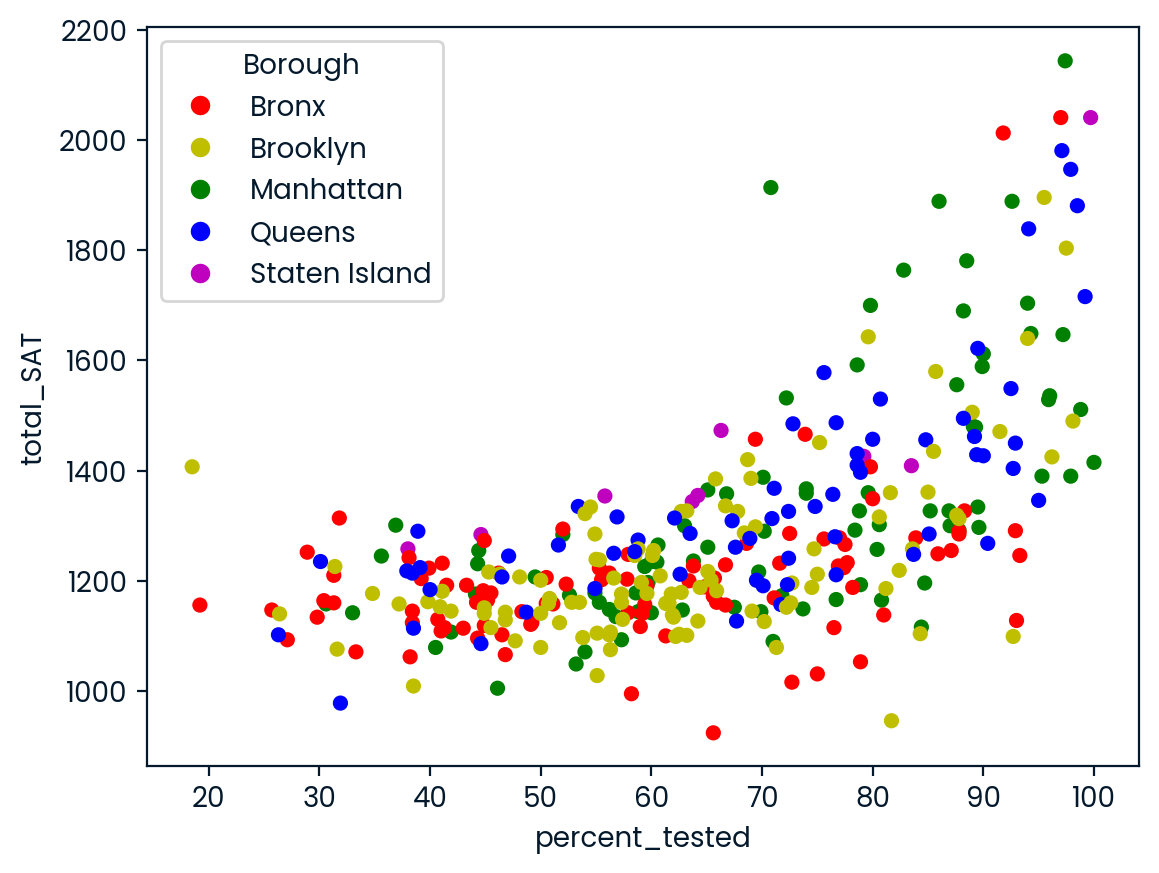

In [6]:
color_map = {
    'Bronx': 'r',
    'Brooklyn': 'y',
    'Manhattan': 'g',
    'Queens': 'b',
    'Staten Island': 'm'
}
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Bronx',
           markerfacecolor='r', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Brooklyn',
           markerfacecolor='y', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Manhattan',
           markerfacecolor='g', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Queens',
           markerfacecolor='b', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Staten Island',
           markerfacecolor='m', markersize=8)
]

schools.plot(
    x='percent_tested',
    y='total_SAT',
    kind='scatter',
    color=schools['borough'].map(color_map)
)

plt.legend(handles=legend_elements, title='Borough')
plt.show()

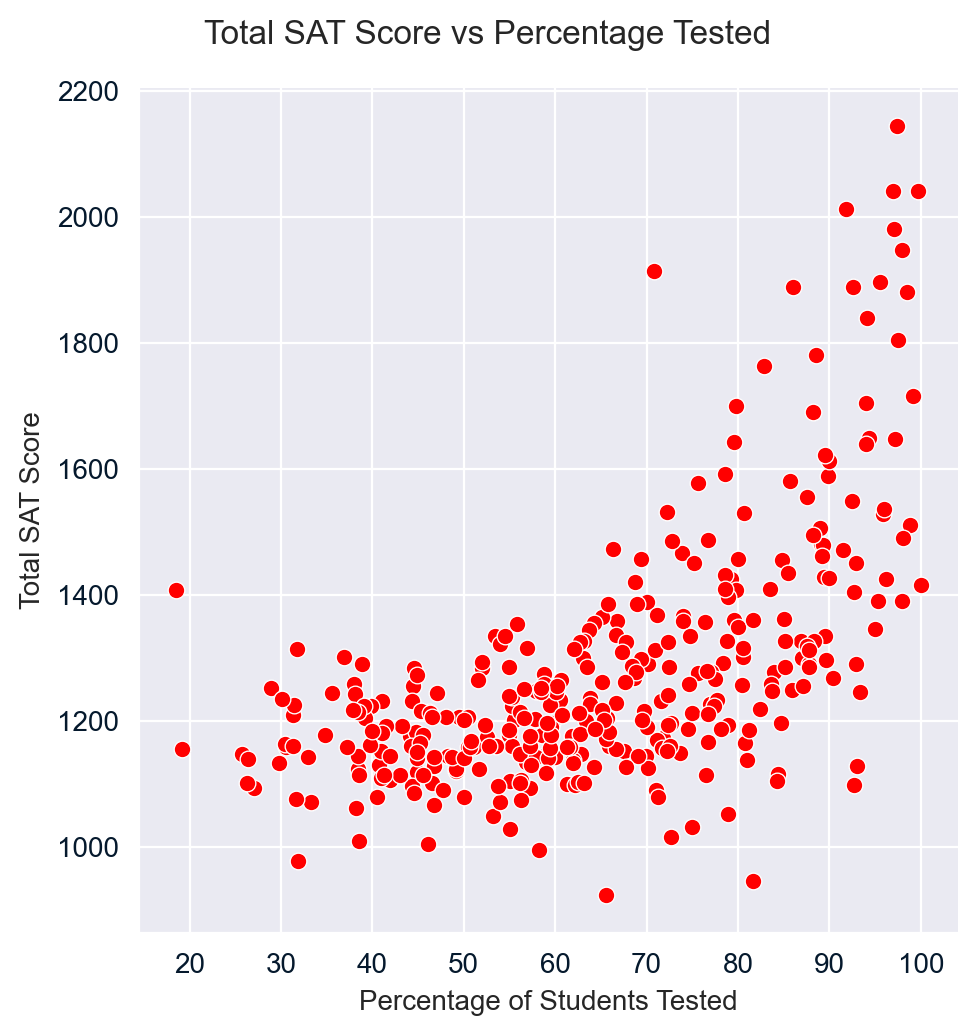

In [6]:
import seaborn as sns
sns.set_style('darkgrid')
g = sns.relplot(x='percent_tested', y='total_SAT', data=schools, kind='scatter' ,color='red')
g.figure.suptitle('Total SAT Score vs Percentage Tested', y=1.03)
g.set(xlabel = 'Percentage of Students Tested', ylabel = 'Total SAT Score')

The scatter plot shows a positive relationship between the percentage of students tested and total SAT scores. Schools with higher testing participation tend to have higher SAT scores. This suggests that, in this dataset, higher participation is associated with stronger performance, contrary to the expectation that selective testing (lower participation) inflates average scores. A possible reason for this could be higher performing schools with high participation rates present in NYC.

In [5]:
borough_participation = schools.groupby('borough')['percent_tested'].mean()
print(borough_participation)

borough
Bronx            58.653763
Brooklyn         62.640385
Manhattan        71.390476
Queens           69.313846
Staten Island    66.111111
Name: percent_tested, dtype: float64


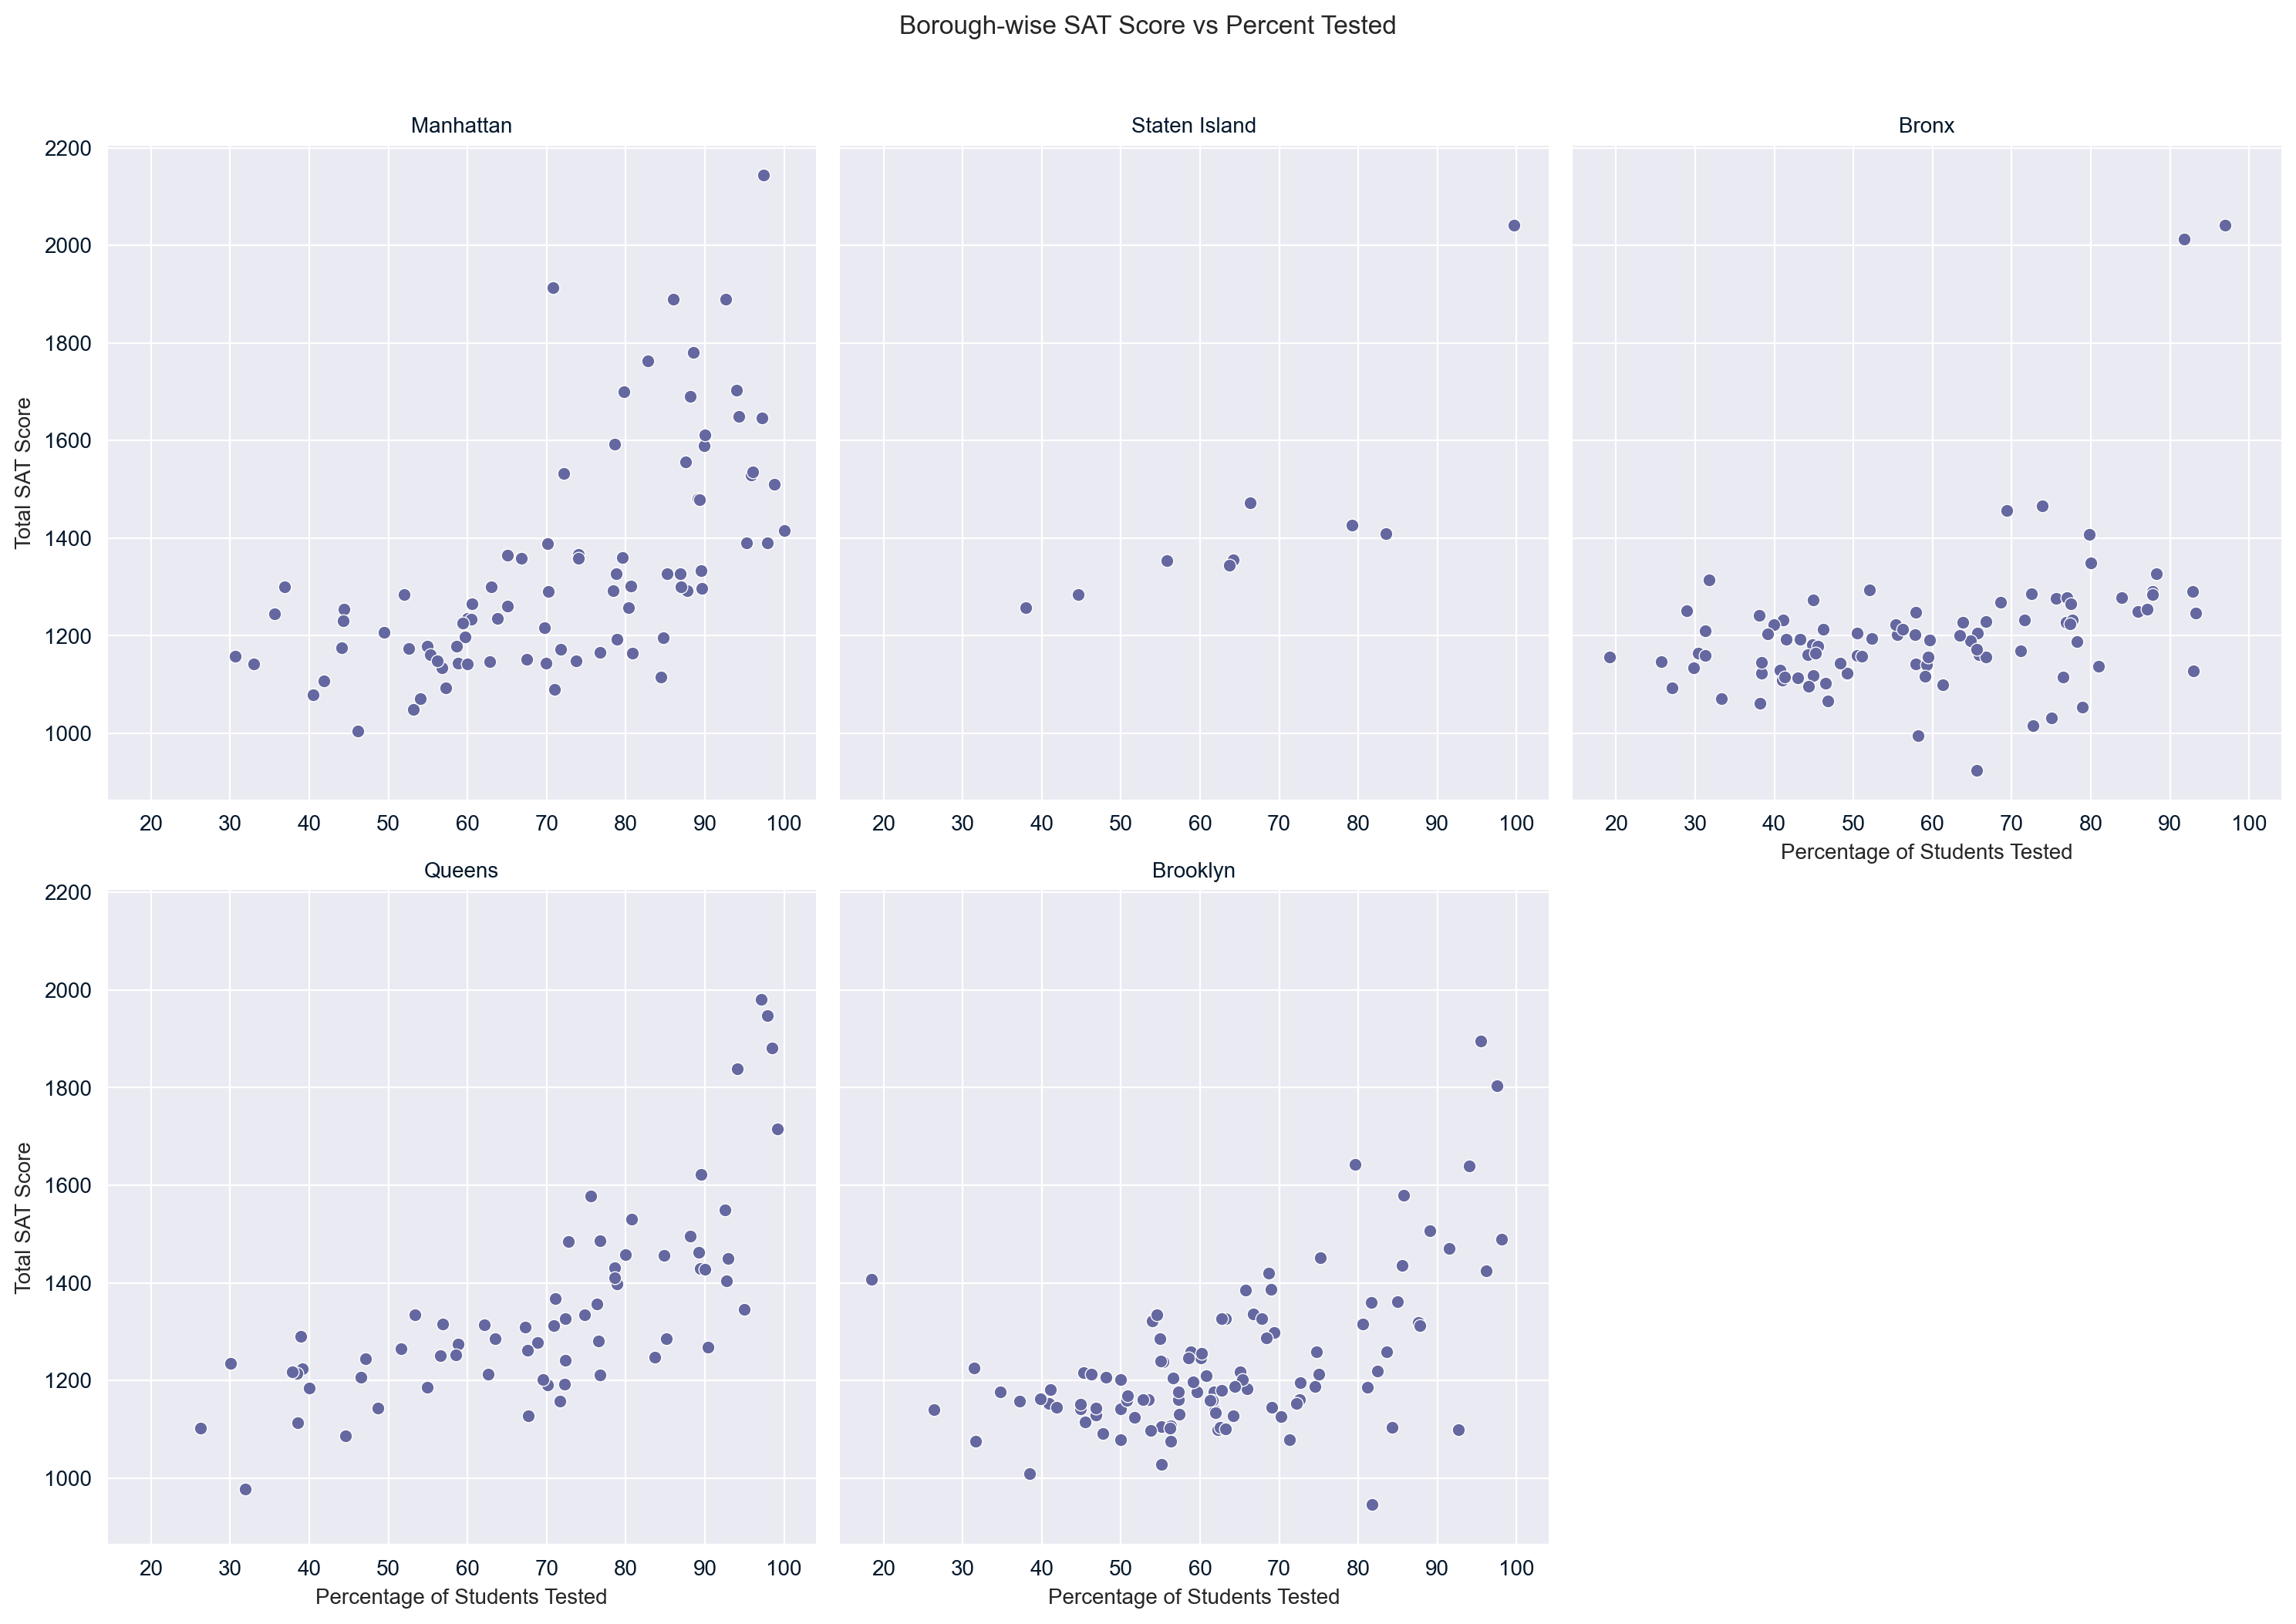

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.relplot(x='percent_tested', y='total_SAT', data=schools, kind='scatter', col = 'borough',col_wrap = 3)
g.figure.suptitle('Borough-wise SAT Score vs Percent Tested', y= 1.05)
g.set_titles('{col_name}')
g.set(xlabel = 'Percentage of Students Tested', ylabel = 'Total SAT Score')
for ax in g.axes.flat:   # if using seaborn FacetGrid
    ax.tick_params(axis='x', labelbottom=True)

The positive relationship observed in the overall plot is not uniform across boroughs. In Queens and Manhattan, there is a clear positive relationship between the percentage of students tested and total SAT scores. This may suggest the presence of several high-performing schools in these boroughs where both participation and academic performance are relatively high.

In Brooklyn, although a positive relationship is still visible, there is greater dispersion in SAT scores across different participation levels. This indicates higher variability in school performance, suggesting the presence of both high-performing and moderately performing schools.

In the Bronx, there is only a slight increase in SAT scores as participation rises, with most schools clustered within a narrower score range. This pattern suggests that many schools in this borough fall within a similar moderate performance band.

Staten Island shows an upward trend between participation and SAT scores; however, the number of schools represented is small, making it difficult to draw strong conclusions.

Overall, the borough-wise analysis suggests that school performance patterns differ across boroughs, and the positive relationship seen in the aggregated data is likely influenced by stronger-performing schools concentrated in certain areas.

## Problem Statement
This project analyzes the relationship between SAT participation rates and total SAT performance across NYC public schools. Using school-level average SAT scores and participation data, the analysis explores whether higher performance is associated with selective testing or broader student participation, and how this relationship varies across boroughs.
## Primary Question
How does SAT participation rate relate to total SAT performance across schools? 
### Secondary Question
Does this relationship differ by borough?

## Data Description
The unit of analysis is school. The schools can be categorised by boroughs. The SAT scores are school-level averages. participation rates vary widely. Analysis shows association not causation. Schools with missing participation data were excluded from participation-based analyses.


**Selection Bias Consideration**
SAT performance metrics can be influenced by who takes the test. However, this analysis finds that the highest SAT scores occur primarily in schools with high participation rates, suggesting that strong performance is not solely driven by selective testing.

# Conclusion

Higher SAT participation is generally associated with higher total SAT performance across NYC schools. However, substantial disparities persist across boroughs, suggesting that participation alone does not explain differences in outcomes. The uneven distribution of high-performing and moderately performing schools across boroughs likely contributes to these observed performance gaps.
